In [16]:

import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patheffects as pe
import pandas as pd
import seaborn as sns
from PIL import Image
from torchvision import transforms, models
from torchvision.models.segmentation import deeplabv3_resnet50

import json
import requests
import zipfile
import torch
import math
import io

In [17]:
# link = "128.32.162.150/bdd100k/bdd100k_images_100k.zip"

In [18]:
from glob import iglob


json_folder = "100k_json"
image_folder = "100k_images"


json_test = os.path.join(json_folder, os.listdir(json_folder)[1])
print(f"JSON test: {json_test}")
json_train = os.path.join(json_folder, os.listdir(json_folder)[2])
print(f"JSON train: {json_train}")
json_val = os.path.join(json_folder, os.listdir(json_folder)[3])
print(f"JSON val: {json_val}")

image_test = os.path.join(image_folder, os.listdir(image_folder)[1])
print(f"Image test: {image_test}")
image_train = os.path.join(image_folder, os.listdir(image_folder)[2])
print(f"Image train: {image_train}")
image_val = os.path.join(image_folder, os.listdir(image_folder)[3])
print(f"Image val: {image_val}")


if os.path.exists(json_test):
    print(f"Folder {json_test} already exists")
else:
    print(f"Folder {json_test} does not exist")
if os.path.exists(image_test):
    print(f"Folder {image_test} already exists")
else:
    print(f"Folder {image_test} does not exist")
if os.path.exists(json_train):
    print(f"Folder {json_train} already exists")
else:
    print(f"Folder {json_train} does not exist")
if os.path.exists(image_train):
    print(f"Folder {image_train} already exists")
else:
    print(f"Folder {image_train} does not exist")
if os.path.exists(json_val):
    print(f"Folder {json_val} already exists")
else:
    print(f"Folder {json_val} does not exist")
if os.path.exists(image_val):
    print(f"Folder {image_val} already exists")

JSON test: 100k_json/test
JSON train: 100k_json/train
JSON val: 100k_json/category_map.json
Image test: 100k_images/test
Image train: 100k_images/train
Image val: 100k_images/val
Folder 100k_json/test already exists
Folder 100k_images/test already exists
Folder 100k_json/train already exists
Folder 100k_images/train already exists
Folder 100k_json/category_map.json already exists
Folder 100k_images/val already exists


In [19]:
os.listdir(json_train)

['3649af95-2ee578d7.json',
 '891947cf-0096f067.json',
 '1c73412f-bc38ec98.json',
 '90afda7c-9720e42b.json',
 '21609974-eafc78dd.json',
 '159577a6-9cd3566e.json',
 'a93aa94e-6d656b8c.json',
 '2b03d428-8abaa40f.json',
 '8a0006bc-6f52b1b6.json',
 '68068bd2-7aa0df89.json',
 '06a741f6-b02c519f.json',
 '2c336fc0-8a379994.json',
 '592aaebe-53f5e41e.json',
 '7f3e059f-4f900bcb.json',
 '462cb79b-690183b3.json',
 '34b2fd3a-cdc2b21a.json',
 '9705d570-9408eb83.json',
 '4e5c39a4-bd403eb8.json',
 '12db9bf7-fc7092f9.json',
 '91d999e3-bc9e4944.json',
 '8fbc39a0-cc304c4c.json',
 '8c4aa33b-72eea9e0.json',
 '55e019fa-315e84e2.json',
 '847068d9-810ff9f0.json',
 '6774b84c-6e2c23e4.json',
 '5024346c-7d855041.json',
 '59dab1df-2cf44f9a.json',
 '74a8ecc2-3524f96c.json',
 '4119abfa-06e9d646.json',
 'abb4a069-49959b47.json',
 '363771c2-1b968052.json',
 '7d048364-1805106f.json',
 '69bd9c64-2c29f777.json',
 '036f07d5-92c52ed8.json',
 '2e1bcb56-a7e15a37.json',
 '0e2ee232-0aa312da.json',
 '16595e94-27b3ed65.json',
 

In [20]:
j = json.load(open(os.path.join(json_train, os.listdir(json_train)[0])))
name = j["name"] + ".jpg"
if os.path.exists(os.path.join(image_train, name)):
    print(f"Image {name} already exists")

Image 3649af95-2ee578d7.jpg already exists


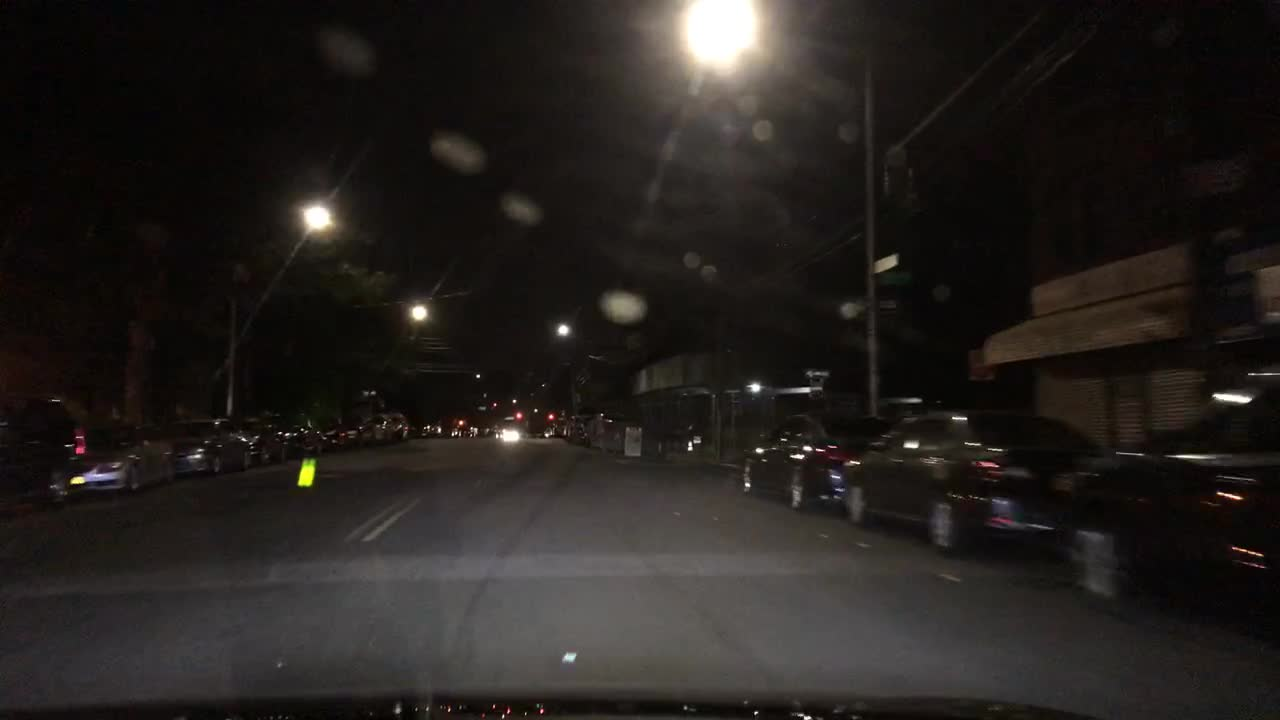

In [21]:
img = Image.open(os.path.join(image_train, name))
img

In [22]:
print(j.keys())
print(j["name"])
print(j["frames"])
print(len(j["frames"]))
print(j["frames"][0].keys())

print(j["frames"][0]["objects"][0].keys())
print(len(j["frames"][0]["objects"]))
print(len(j["frames"][0]["objects"][0]))
print(j["frames"][0]["objects"][0])
print(j["frames"][0]["objects"])


roads = [obj for obj in j["frames"][0]["objects"] if obj["category"] == "area/drivable"]
roads

dict_keys(['name', 'frames', 'attributes'])
3649af95-2ee578d7
[{'timestamp': 10000, 'objects': [{'category': 'traffic sign', 'id': 0, 'attributes': {'occluded': False, 'truncated': False, 'trafficLightColor': 'none'}, 'box2d': {'x1': 874.356425, 'y1': 253.46232, 'x2': 894.606411, 'y2': 273.712307}}, {'category': 'traffic sign', 'id': 1, 'attributes': {'occluded': True, 'truncated': False, 'trafficLightColor': 'none'}, 'box2d': {'x1': 874.356425, 'y1': 266.962311, 'x2': 913.168898, 'y2': 285.524799}}, {'category': 'traffic sign', 'id': 2, 'attributes': {'occluded': True, 'truncated': False, 'trafficLightColor': 'none'}, 'box2d': {'x1': 854.106439, 'y1': 293.962293, 'x2': 899.668908, 'y2': 310.837281}}, {'category': 'traffic sign', 'id': 3, 'attributes': {'occluded': True, 'truncated': False, 'trafficLightColor': 'none'}, 'box2d': {'x1': 965.481362, 'y1': 344.587258, 'x2': 995.856343, 'y2': 380.024734}}, {'category': 'traffic light', 'id': 4, 'attributes': {'occluded': False, 'truncated'

[{'category': 'area/drivable',
  'id': 29,
  'attributes': {},
  'poly2d': [[500.603324, 442.748513, 'L'],
   [570.026279, 443.341057, 'L'],
   [1279.774383, 700.866208, 'L'],
   [1279.774383, 720.756371, 'L'],
   [1097.638786, 720.756371, 'L'],
   [1097.929942, 691.506642, 'C'],
   [472.669212, 672.601251, 'C'],
   [160.184423, 702.436483, 'C'],
   [500.603324, 442.748513, 'L']]}]

In [23]:
objects = j["frames"][0]["objects"]

roads = [obj for obj in objects if obj["category"] == "area/drivable"]
lanes = [obj for obj in objects if obj["category"].startswith("lane/")]
road_all = [
    obj for obj in objects if "area" in obj["category"] or "lane" in obj["category"]
]

print(f"Drivable areas : {len(roads)}")
print(f"Lane markings  : {len(lanes)}")
print(f"All road objs  : {len(road_all)}")
print()
print("Roads:", roads)
print()
print("Lanes:", lanes)

Drivable areas : 1
Lane markings  : 3
All road objs  : 4

Roads: [{'category': 'area/drivable', 'id': 29, 'attributes': {}, 'poly2d': [[500.603324, 442.748513, 'L'], [570.026279, 443.341057, 'L'], [1279.774383, 700.866208, 'L'], [1279.774383, 720.756371, 'L'], [1097.638786, 720.756371, 'L'], [1097.929942, 691.506642, 'C'], [472.669212, 672.601251, 'C'], [160.184423, 702.436483, 'C'], [500.603324, 442.748513, 'L']]}]

Lanes: [{'category': 'lane/road curb', 'id': 30, 'attributes': {'direction': 'parallel', 'style': 'solid'}, 'poly2d': [[704.253488, 469.600442, 'L'], [743.486599, 479.408931, 'L']]}, {'category': 'lane/double yellow', 'id': 31, 'attributes': {'direction': 'parallel', 'style': 'solid'}, 'poly2d': [[421.775093, 500.987599, 'L'], [370.77205, 541.202394, 'L']]}, {'category': 'lane/double yellow', 'id': 32, 'attributes': {'direction': 'parallel', 'style': 'solid'}, 'poly2d': [[404.120195, 492.159962, 'L'], [341.347217, 539.240697, 'L']]}]


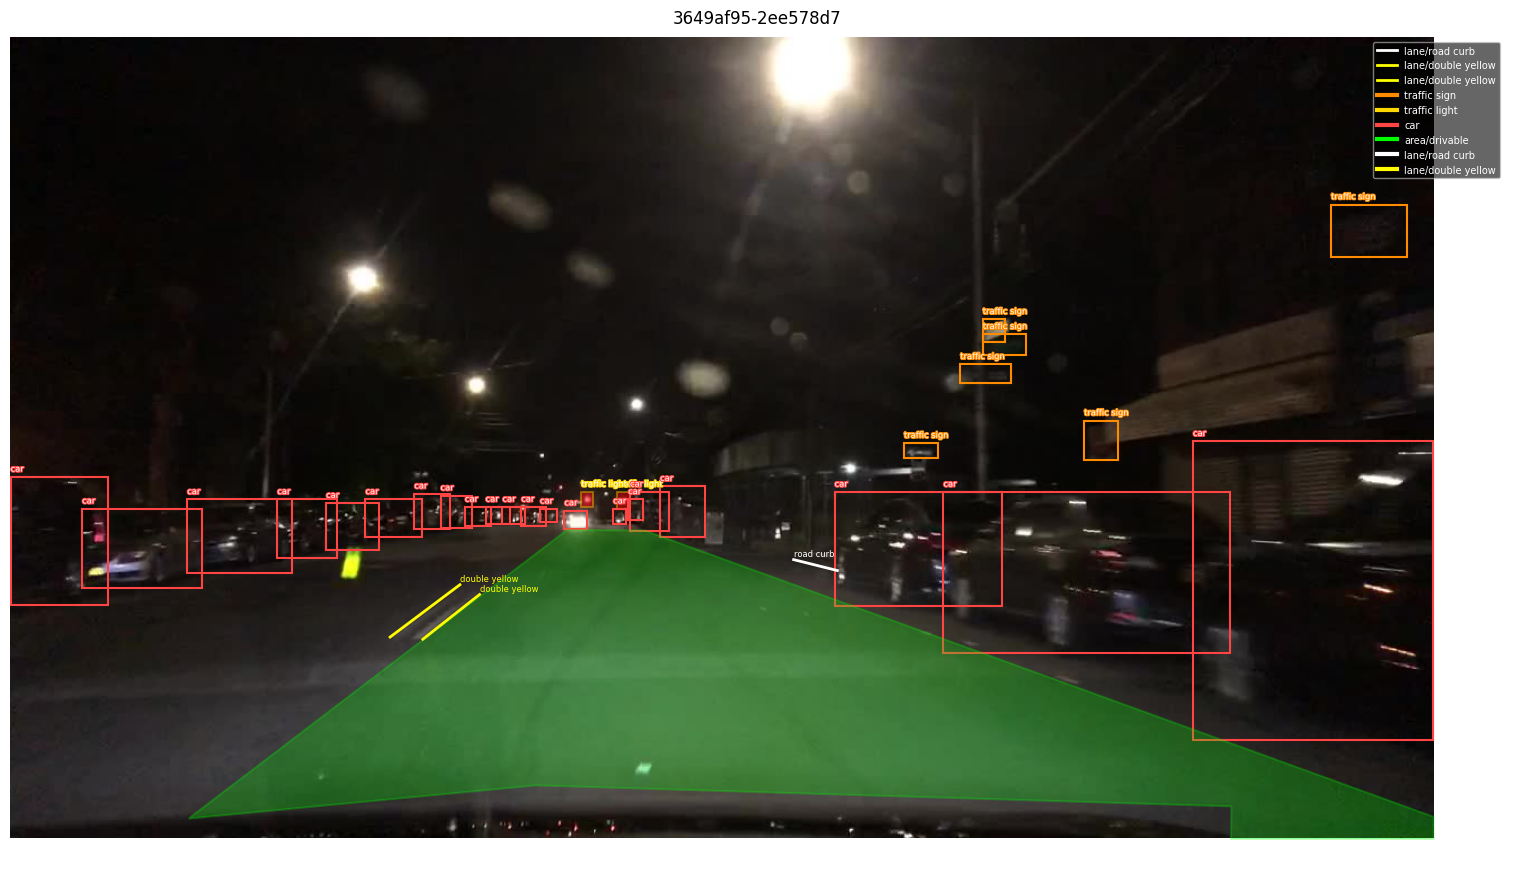

In [24]:
# Color map per category
COLORS = {
    "car": "#FF4444",
    "traffic light": "#FFD700",
    "traffic sign": "#FF8C00",
    "person": "#AA44FF",
    "rider": "#FF44AA",
    "truck": "#4444FF",
    "bus": "#00AAFF",
    "bike": "#00FFAA",
    "motor": "#FF6600",
    "area/drivable": "#00FF00",
    "lane/road curb": "#FFFFFF",
    "lane/double yellow": "#FFFF00",
    "lane/single white": "#CCCCCC",
}
DEFAULT_COLOR = "#888888"

TRAFFIC_LIGHT_COLORS = {
    "red": "red",
    "green": "lime",
    "yellow": "yellow",
    "none": "gray",
}

fig, ax = plt.subplots(1, 1, figsize=(16, 9))
ax.imshow(img)
ax.axis("off")
ax.set_title(j["name"], fontsize=12, pad=10)

for obj in objects:
    cat = obj["category"]
    color = COLORS.get(cat, DEFAULT_COLOR)

    # --- Bounding box objects (cars, traffic signs, lights, etc.) ---
    if "box2d" in obj:
        b = obj["box2d"]
        x1, y1, x2, y2 = b["x1"], b["y1"], b["x2"], b["y2"]
        w, h = x2 - x1, y2 - y1

        # For traffic lights, use the signal color as fill
        if cat == "traffic light":
            sig_color = TRAFFIC_LIGHT_COLORS.get(
                obj["attributes"].get("trafficLightColor", "none"), "gray"
            )
            rect = patches.Rectangle(
                (x1, y1),
                w,
                h,
                linewidth=1.5,
                edgecolor=color,
                facecolor=sig_color,
                alpha=0.4,
            )
        else:
            rect = patches.Rectangle(
                (x1, y1), w, h, linewidth=1.5, edgecolor=color, facecolor="none"
            )
        ax.add_patch(rect)

        # Label
        label = cat.split("/")[-1]
        txt = ax.text(x1, y1 - 3, label, fontsize=6, color="white", va="bottom")
        txt.set_path_effects([pe.withStroke(linewidth=1.5, foreground=color)])

    # --- Polygon objects (drivable area, lanes) ---
    elif "poly2d" in obj:
        pts = [(p[0], p[1]) for p in obj["poly2d"]]
        if len(pts) < 2:
            continue
        xs, ys = zip(*pts)

        if cat == "area/drivable":
            poly = patches.Polygon(
                list(zip(xs, ys)),
                closed=True,
                edgecolor=color,
                facecolor=color,
                alpha=0.25,
                linewidth=1.5,
            )
            ax.add_patch(poly)
        else:
            # Lanes: just draw the line
            ax.plot(xs, ys, color=color, linewidth=2, label=cat)
            ax.text(xs[0], ys[0] - 3, cat.split("/")[-1], fontsize=6, color=color)

# Legend (deduplicated)
seen = set()
for obj in objects:
    cat = obj["category"]
    if cat not in seen:
        color = COLORS.get(cat, DEFAULT_COLOR)
        ax.plot([], [], color=color, linewidth=3, label=cat)
        seen.add(cat)
ax.legend(
    loc="upper right", fontsize=7, framealpha=0.6, facecolor="black", labelcolor="white"
)

plt.tight_layout()
plt.show()

In [25]:
model = deeplabv3_resnet50(progress = True)
model

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [26]:
iter = 2
max_iter = 10
power = 0.9
learning_rate = math.pow((1 - iter/max_iter), power)
crop = 512
batch_size = 16
output_stride = 16
decay = 0.9997

# data augmentation
# randomly scaling input images from 0.5 to 2
# and random left-right flipping during training

In [27]:
model.eval()

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [ ]:
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img)

input_batch = input_tensor.unsqueeze(0) 
    input_batch = input_batch.to('cuda')
    model.to('cuda')

with torch.no_grad():
    output = model(input_batch)['out'][0]
output_predictions = output.argmax(0)


In [25]:
output_predictions

tensor([[ 2,  2,  2,  ..., 10, 10, 10],
        [ 2,  2,  2,  ..., 10, 10, 10],
        [ 2,  2,  2,  ..., 10, 10, 10],
        ...,
        [10, 10, 10,  ..., 10, 10, 10],
        [10, 10, 10,  ..., 10, 10, 10],
        [10, 10, 10,  ..., 10, 10, 10]])

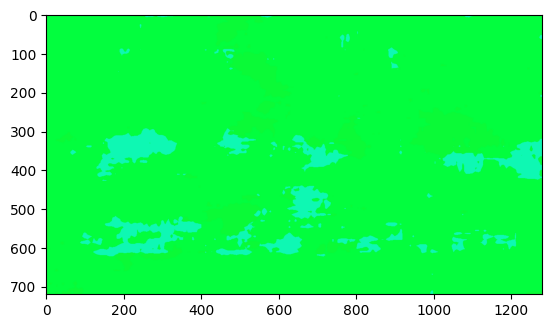

In [26]:
palette = torch.tensor([2 ** 25 - 1, 2 ** 15 - 1, 2 ** 21 - 1])
colors = torch.as_tensor([i for i in range(21)])[:, None] * palette
colors = (colors % 255).numpy().astype("uint8")

# plot the semantic segmentation predictions of 21 classes in each color
r = Image.fromarray(output_predictions.byte().cpu().numpy()).resize(img.size)
r.putpalette(colors)

import matplotlib.pyplot as plt
plt.imshow(r)